# 04. Baseline Models for NBA Prediction Tasks


## 1. Research Goal

Цель этапа состоит в построении воспроизводимых baseline и classical ML-моделей для двух задач: прогнозирование победителя матча и прогнозирование очков игрока. Этап проверяет информативность подготовленных признаков, фиксирует сильные табличные ориентиры качества и формирует базу для последующего сравнения с deep learning.

Исследовательские гипотезы:

H1: ансамблевые деревянные модели дают более высокое качество на табличных NBA-данных, чем простые линейные модели.

H2: признаки формы команды, состава, финансового и новостного контекста дают измеримый сигнал для прогноза победителя матча.

H3: историческая форма игрока и его игровая роль позволяют прогнозировать количество очков в следующем матче лучше наивного baseline.


## 2. Environment Setup

Раздел задает воспроизводимую вычислительную среду, каталоги результатов и ограничения производительности. Код рассчитан на запуск в Google Colab и локально из корня проекта.


In [ ]:
import json
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge, RidgeClassifier, ElasticNet
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

import joblib

try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier = None
    XGBRegressor = None
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except Exception:
    LGBMClassifier = None
    LGBMRegressor = None
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
except Exception:
    CatBoostClassifier = None
    CatBoostRegressor = None

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 60)

MAX_ROWS_FOR_BASE_MODELS = 120_000
MAX_ROWS_FOR_HEAVY_MODELS = 50_000
MAX_ROWS_FOR_KNN = 40_000
TUNING_N_ITER = 8


In [ ]:
def first_existing_path(candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    return Path(candidates[0])

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MATCH_DATASET_PATH = first_existing_path([
    PROJECT_ROOT / "data/processed/match_prediction_dataset.csv",
    PROJECT_ROOT / "match_prediction_dataset.csv",
    Path("/content/match_prediction_dataset.csv"),
])
MATCH_FEATURE_SETS_PATH = first_existing_path([
    PROJECT_ROOT / "data/processed/match_prediction_feature_sets.json",
    PROJECT_ROOT / "match_prediction_feature_sets.json",
    Path("/content/match_prediction_feature_sets.json"),
])
PLAYER_POINTS_DATASET_PATH = first_existing_path([
    PROJECT_ROOT / "data/processed/player_points_prediction_dataset.csv",
    PROJECT_ROOT / "player_points_prediction_dataset.csv",
    Path("/content/player_points_prediction_dataset.csv"),
])
PLAYER_POINTS_FEATURE_SETS_PATH = first_existing_path([
    PROJECT_ROOT / "data/processed/player_points_feature_sets.json",
    PROJECT_ROOT / "player_points_feature_sets.json",
    Path("/content/player_points_feature_sets.json"),
])

ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/baseline"
FIG_DIR = ARTIFACT_ROOT / "figures"
MODEL_DIR = ARTIFACT_ROOT / "models"
TABLE_DIR = ARTIFACT_ROOT / "tables"
REPORT_DIR = PROJECT_ROOT / "data/reports"
DOCS_DIR = PROJECT_ROOT / "docs"
for p in [FIG_DIR, MODEL_DIR, TABLE_DIR, REPORT_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [MATCH_DATASET_PATH, MATCH_FEATURE_SETS_PATH, PLAYER_POINTS_DATASET_PATH, PLAYER_POINTS_FEATURE_SETS_PATH]:
    print(p)


/content/match_prediction_dataset.csv
/content/match_prediction_feature_sets.json
/content/player_points_prediction_dataset.csv
/content/player_points_feature_sets.json


## 3. Utility Functions

Раздел содержит функции загрузки, валидации, очистки, feature engineering, временного разбиения, расчета метрик, визуализации и сохранения результатов.


In [ ]:
def load_json(path: str | Path) -> dict:
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def check_file_exists(path: str | Path) -> None:
    if not Path(path).exists():
        raise FileNotFoundError(f"Файл не найден: {path}. В Colab загрузите файл в /content или подключите Google Drive.")


def validate_required_columns(df: pd.DataFrame, required: list[str], dataset_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"В {dataset_name} отсутствуют обязательные колонки: {missing}")


def validate_columns(df: pd.DataFrame, columns: list[str], label: str) -> list[str]:
    missing = [c for c in columns if c not in df.columns]
    if missing:
        print(f"Предупреждение [{label}]: отсутствуют {len(missing)} колонок; первые: {missing[:12]}")
    return [c for c in columns if c in df.columns]


def save_results_table(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def summarize_dataset(df: pd.DataFrame, date_col: str, target_col: str, entity_cols: list[str], name: str) -> pd.DataFrame:
    row = {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicates": int(df.duplicated().sum()),
        "date_min": df[date_col].min(),
        "date_max": df[date_col].max(),
        "target_missing": int(df[target_col].isna().sum()),
        "target_mean": float(df[target_col].mean()),
        "mean_missing_share": float(df.isna().mean().mean()),
    }
    for col in entity_cols:
        if col in df.columns:
            row[f"n_{col}"] = df[col].nunique(dropna=True)
    return pd.DataFrame([row])


def clean_model_dataset(df, date_col, target_col, dataset_name, min_year=1980, target_min=None, target_max=None):
    d = df.copy()
    validate_required_columns(d, [date_col, target_col], dataset_name)
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col, target_col]).copy()
    d = d[d[date_col].dt.year >= min_year].copy()
    if target_min is not None:
        d = d[d[target_col] >= target_min].copy()
    if target_max is not None:
        d = d[d[target_col] <= target_max].copy()
    d = d.replace([np.inf, -np.inf], np.nan).drop_duplicates()
    d = d.sort_values(date_col).reset_index(drop=True)
    if d.empty:
        raise ValueError(f"После очистки датасет {dataset_name} пуст.")
    return d


def chronological_split(df, date_col, train_size=0.70, val_size=0.15):
    d = df.sort_values(date_col).reset_index(drop=True)
    n = len(d)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    if train_end == 0 or val_end <= train_end or val_end >= n:
        raise ValueError("Недостаточно строк для хронологического train/validation/test split.")
    return d.iloc[:train_end].copy(), d.iloc[train_end:val_end].copy(), d.iloc[val_end:].copy()


def split_report(train_df, val_df, test_df, date_col, target_col):
    rows = []
    for label, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        rows.append({
            "split": label,
            "rows": len(part),
            "date_min": part[date_col].min(),
            "date_max": part[date_col].max(),
            "target_mean": part[target_col].mean(),
            "target_std": part[target_col].std(),
        })
    return pd.DataFrame(rows)


def get_feature_group(feature_sets: dict, key: str, df: pd.DataFrame) -> list[str]:
    values = feature_sets.get(key, [])
    if not values:
        print(f"Предупреждение: группа признаков '{key}' отсутствует или пуста.")
    return [c for c in values if c in df.columns]


def remove_potential_leakage_features(features: list[str], target_col: str, task: str) -> list[str]:
    leakage_exact = {target_col, "target", "label", "is_win", "win", "won", "result", "outcome"}
    leakage_tokens = ["future", "post_game", "final", "actual", "target"]
    if task == "match":
        leakage_tokens += ["team_score", "opponent_score", "plus_minus", "margin"]
    cleaned = []
    for col in dict.fromkeys(features):
        low = col.lower()
        if low in leakage_exact or any(token in low for token in leakage_tokens):
            continue
        cleaned.append(col)
    if len(cleaned) < len(features):
        print(f"Удалены потенциально утекающие признаки ({task}): {len(features) - len(cleaned)}")
    return cleaned


def add_ratio_features(df: pd.DataFrame, features: list[str], max_new_features=24):
    d = df.copy()
    numeric_features = [c for c in features if c in d.columns and pd.api.types.is_numeric_dtype(d[c])]
    pairs = []
    for c in numeric_features:
        low = c.lower()
        if low.endswith("_for"):
            pairs.append((c, c[:-4] + "_against"))
        if "home" in low:
            pairs.append((c, c.replace("home", "away")))
        if "team" in low:
            pairs.append((c, c.replace("team", "opponent")))
    new_features = []
    for left, right in pairs:
        if len(new_features) >= max_new_features:
            break
        if left in d.columns and right in d.columns and left != right:
            diff_col = f"fe_diff__{left}__{right}"[:120]
            ratio_col = f"fe_ratio__{left}__{right}"[:120]
            d[diff_col] = pd.to_numeric(d[left], errors="coerce") - pd.to_numeric(d[right], errors="coerce")
            denom = pd.to_numeric(d[right], errors="coerce").replace(0, np.nan)
            d[ratio_col] = pd.to_numeric(d[left], errors="coerce") / denom
            new_features.extend([diff_col, ratio_col])
    return d, features + new_features


def get_numeric_feature_frame(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    X = df[[c for c in features if c in df.columns]].copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    keep = X.nunique(dropna=True)
    return X[keep[keep > 1].index.tolist()]


def sample_training_data(X, y, limit, random_state=RANDOM_STATE):
    if len(X) <= limit:
        return X, y, False
    idx = X.sample(limit, random_state=random_state).index
    return X.loc[idx], y.loc[idx], True


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > 1e-9
    return np.nan if mask.sum() == 0 else float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def classification_metrics(y_true, y_pred, y_score=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": np.nan,
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            pass
    return out


def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape": safe_mape(y_true, y_pred),
    }


def build_pipeline(pipe_type: str, estimator):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if pipe_type == "scaled":
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)


def predict_classification_outputs(model, X):
    pred = model.predict(X)
    score = None
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
            if np.ndim(proba) == 2 and proba.shape[1] > 1:
                score = proba[:, 1]
        except Exception:
            pass
    if score is None and hasattr(model, "decision_function"):
        try:
            score = np.asarray(model.decision_function(X), dtype=float)
            if score.ndim > 1:
                score = score[:, 1]
        except Exception:
            pass
    return pred, score


def plot_barh_top(results_df, metric_col, ascending, title, xlabel, output_path):
    d = results_df[results_df["status"].eq("trained")].dropna(subset=[metric_col]).copy()
    if d.empty:
        return
    d = d.sort_values(metric_col, ascending=ascending).head(15)
    plt.figure(figsize=(10, 5))
    plt.barh(d["model"] + " | " + d["feature_set"], d[metric_col])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title, output_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks([0, 1], [0, 1])
    plt.yticks([0, 1], [0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def plot_regression_actual_vs_predicted(y_true, y_pred, title, output_path):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.25, s=10)
    lo = float(np.nanmin([np.nanmin(y_true), np.nanmin(y_pred)]))
    hi = float(np.nanmax([np.nanmax(y_true), np.nanmax(y_pred)]))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def plot_residual_distribution(y_true, y_pred, title, output_path):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=40)
    plt.title(title)
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def get_feature_importance(model, feature_names):
    estimator = model.named_steps.get("model", model) if hasattr(model, "named_steps") else model
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        coef = estimator.coef_
        importance = np.abs(coef[0]) if np.ndim(coef) > 1 else np.abs(coef)
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    n = min(len(feature_names), len(importance))
    return pd.DataFrame({"feature": feature_names[:n], "importance": importance[:n]}).sort_values("importance", ascending=False)


## 4. Part 1 Research Setup

Задача 1 формулируется как бинарная классификация на уровне «команда × матч» с целевой переменной target_win.


In [ ]:
for p in [MATCH_DATASET_PATH, MATCH_FEATURE_SETS_PATH, PLAYER_POINTS_DATASET_PATH, PLAYER_POINTS_FEATURE_SETS_PATH]:
    check_file_exists(p)

match_df_raw = pd.read_csv(MATCH_DATASET_PATH)
match_feature_sets = load_json(MATCH_FEATURE_SETS_PATH)
print(f"match_df_raw shape: {match_df_raw.shape}")


match_df_raw shape: (129609, 303)


## 5. Load Match Prediction Dataset

Проводится базовая проверка качества данных: обязательные поля, корректность дат, диапазон целевой переменной, дубликаты и доля пропусков.


In [ ]:
match_df = clean_model_dataset(
    match_df_raw, "game_date", "target_win", "match prediction dataset", min_year=1980, target_min=0, target_max=1
)
match_df["target_win"] = match_df["target_win"].astype(int)
match_summary = summarize_dataset(match_df, "game_date", "target_win", ["team", "opponent", "game_id"], "match_prediction_dataset")
save_results_table(match_summary, TABLE_DIR / "match_dataset_quality_summary.csv")
display(match_summary)


,dataset,rows,columns,duplicates,date_min,date_max,target_missing,target_mean,mean_missing_share,n_team,n_opponent,n_game_id
0,match_prediction_dataset,97393,303,0,1980-01-01,2023-04-05,0,0.499923,0.574246,43,43,48697


## 6. Match Feature Set Selection

Используются подготовленные группы признаков. Дополнительно удаляются потенциально утекающие признаки и добавляется компактный набор разностных/ratio-признаков.


In [ ]:
sport = get_feature_group(match_feature_sets, "sport_form_features", match_df)
composition = get_feature_group(match_feature_sets, "composition_features", match_df)
financial = get_feature_group(match_feature_sets, "financial_features", match_df)
news = get_feature_group(match_feature_sets, "news_features", match_df)
opponent = get_feature_group(match_feature_sets, "opponent_features", match_df)
diff = get_feature_group(match_feature_sets, "diff_features", match_df)
all_features = get_feature_group(match_feature_sets, "all_model_features", match_df)
if not all_features:
    all_features = sorted(set(sport + composition + financial + news + opponent + diff))

all_features = remove_potential_leakage_features(all_features, "target_win", task="match")
match_df, all_features = add_ratio_features(match_df, all_features, max_new_features=20)
match_feature_ablation = {
    "sport_form": sorted(set(remove_potential_leakage_features(sport + opponent + diff, "target_win", task="match"))),
    "sport_plus_context": sorted(set(remove_potential_leakage_features(sport + opponent + diff + composition + financial + news, "target_win", task="match"))),
    "all_features": sorted(set(all_features)),
}
match_feature_ablation = {k: validate_columns(match_df, v, f"match:{k}") for k, v in match_feature_ablation.items() if v}
match_feature_set_summary = pd.DataFrame([{"feature_set": k, "n_features": len(v)} for k, v in match_feature_ablation.items()])
save_results_table(match_feature_set_summary, TABLE_DIR / "match_feature_set_summary.csv")
display(match_feature_set_summary)


Удалены потенциально утекающие признаки (match): 39
Удалены потенциально утекающие признаки (match): 60


,feature_set,n_features
0,sport_form,225
1,sport_plus_context,290
2,all_features,296


## 7. Match Chronological Split

Используется хронологическое разбиение 70/15/15. Валидация применяется для выбора модели и гиперпараметров; test используется только для финальной оценки.


In [ ]:
match_train, match_val, match_test = chronological_split(match_df, "game_date", 0.70, 0.15)
match_split_summary = split_report(match_train, match_val, match_test, "game_date", "target_win")
save_results_table(match_split_summary, TABLE_DIR / "match_split_summary.csv")
display(match_split_summary)


,split,rows,date_min,date_max,target_mean,target_std
0,train,68175,1980-01-01,2011-02-11,0.499993,0.500004
1,validation,14609,2011-02-11,2017-03-08,0.500171,0.500017
2,test,14609,2017-03-08,2023-04-05,0.499350,0.500017


## 8. Match Classification Model Zoo

Набор моделей оставлен компактным: dummy-baseline, линейные модели, KNN, дерево, random forest, extra trees и gradient boosting. Внешние boosting-библиотеки используются только при наличии в среде.


In [ ]:
def model_rec(name, family, estimator, pipe="tree", heavy=False, knn=False):
    return {"name": name, "family": family, "estimator": estimator, "pipe": pipe, "heavy": heavy, "knn": knn}

clf_models = [
    model_rec("Dummy_most_frequent", "dummy", DummyClassifier(strategy="most_frequent")),
    model_rec("Dummy_stratified", "dummy", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    model_rec("LogisticRegression", "linear", LogisticRegression(max_iter=700, random_state=RANDOM_STATE), "scaled"),
    model_rec("LogisticRegression_balanced", "linear", LogisticRegression(max_iter=700, class_weight="balanced", random_state=RANDOM_STATE), "scaled"),
    model_rec("RidgeClassifier", "linear", RidgeClassifier(), "scaled"),
    model_rec("LinearSVC", "svm", LinearSVC(random_state=RANDOM_STATE, max_iter=2500), "scaled"),
    model_rec("KNeighborsClassifier", "metric", KNeighborsClassifier(n_neighbors=21), "scaled", knn=True),
    model_rec("DecisionTreeClassifier", "tree", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8, min_samples_leaf=10)),
    model_rec("RandomForestClassifier", "tree_ensemble", RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12, min_samples_leaf=5), heavy=True),
    model_rec("ExtraTreesClassifier", "tree_ensemble", ExtraTreesClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12, min_samples_leaf=5), heavy=True),
    model_rec("GradientBoostingClassifier", "boosting", GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=80, learning_rate=0.06, max_depth=2), heavy=True),
    model_rec("HistGradientBoostingClassifier", "boosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=80, learning_rate=0.06, max_leaf_nodes=15), heavy=True),
]
if XGBClassifier is not None:
    clf_models.append(model_rec("XGBClassifier", "external_boosting", XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.07, max_depth=4, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss"), heavy=True))
if LGBMClassifier is not None:
    clf_models.append(model_rec("LGBMClassifier", "external_boosting", LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.07, max_depth=8, verbose=-1), heavy=True))
if CatBoostClassifier is not None:
    clf_models.append(model_rec("CatBoostClassifier", "external_boosting", CatBoostClassifier(random_state=RANDOM_STATE, iterations=100, learning_rate=0.07, depth=5, verbose=False), heavy=True))

display(pd.DataFrame([{k: v for k, v in rec.items() if k != "estimator"} for rec in clf_models]))


,name,family,pipe,heavy,knn
0,Dummy_most_frequent,dummy,tree,False,False
1,Dummy_stratified,dummy,tree,False,False
2,LogisticRegression,linear,scaled,False,False
3,LogisticRegression_balanced,linear,scaled,False,False
4,RidgeClassifier,linear,scaled,False,False
5,LinearSVC,svm,scaled,False,False
6,KNeighborsClassifier,metric,scaled,False,True
7,DecisionTreeClassifier,tree,tree,False,False
8,RandomForestClassifier,tree_ensemble,tree,True,False
9,ExtraTreesClassifier,tree_ensemble,tree,True,False


## 9. Match Baseline Training Loop

Все модели обучаются только на train. Качество считается на validation и test, но ранжирование для исследовательского выбора выполняется по validation.


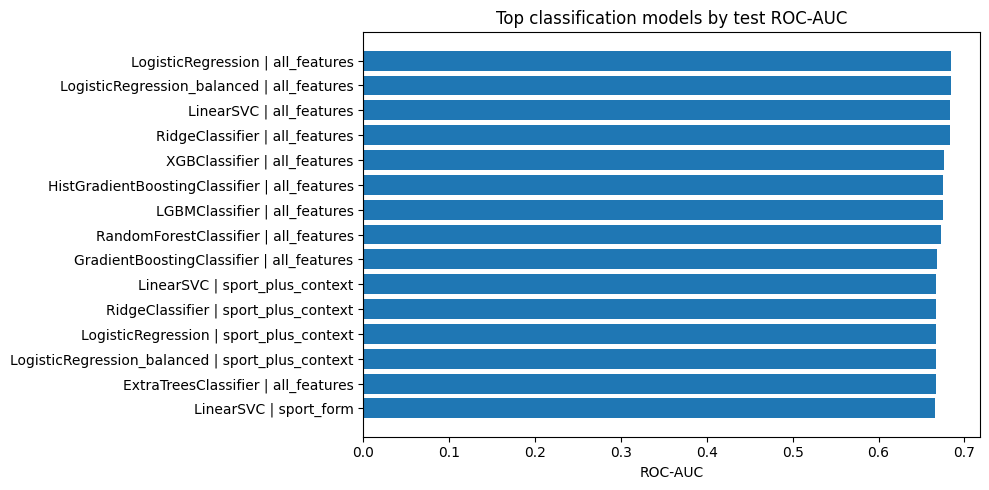

,task,feature_set,model_family,model,status,trained_on_sample,fit_time_sec,predict_time_sec,split_type,n_features,n_train,n_val,n_test,accuracy_val,precision_val,recall_val,f1_val,roc_auc_val,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,main_validation_metric,main_test_metric,params,error_message,comment_for_thesis
31,match_winner_classification,all_features,linear,LogisticRegression_balanced,trained,False,5.536260,0.166159,chronological,127,68175,14609,14609,0.656924,0.654879,0.664021,0.659418,0.722002,0.631939,0.631298,0.632077,0.631687,0.683857,0.722002,0.683857,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
30,match_winner_classification,all_features,linear,LogisticRegression,trained,False,4.726136,0.171978,chronological,127,68175,14609,14609,0.656924,0.654879,0.664021,0.659418,0.722001,0.632076,0.631471,0.632077,0.631774,0.683857,0.722001,0.683857,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
33,match_winner_classification,all_features,svm,LinearSVC,trained,False,16.389419,0.136618,chronological,127,68175,14609,14609,0.656171,0.654199,0.663063,0.658601,0.721528,0.631802,0.631449,0.630843,0.631146,0.683535,0.721528,0.683535,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
32,match_winner_classification,all_features,linear,RidgeClassifier,trained,False,1.501010,0.143890,chronological,127,68175,14609,14609,0.656034,0.653981,0.663200,0.658558,0.721464,0.631529,0.631175,0.630569,0.630872,0.683480,0.721464,0.683480,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
40,match_winner_classification,all_features,external_boosting,XGBClassifier,trained,True,3.867736,0.184725,chronological,127,68175,14609,14609,0.654049,0.649344,0.670316,0.659663,0.716502,0.625299,0.619976,0.644962,0.632223,0.675618,0.716502,0.675618,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
41,match_winner_classification,all_features,external_boosting,LGBMClassifier,trained,True,5.745178,0.455990,chronological,127,68175,14609,14609,0.654254,0.648970,0.672506,0.660528,0.716230,0.623383,0.614627,0.658944,0.636015,0.674797,0.716230,0.674797,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
39,match_winner_classification,all_features,boosting,HistGradientBoostingClassifier,trained,True,4.460988,0.585314,chronological,127,68175,14609,14609,0.653844,0.649125,0.670179,0.659484,0.715204,0.625436,0.621130,0.640713,0.630769,0.675352,0.715204,0.675352,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
36,match_winner_classification,all_features,tree_ensemble,RandomForestClassifier,trained,True,31.127494,1.222028,chronological,127,68175,14609,14609,0.652680,0.646927,0.672780,0.659600,0.712311,0.625231,0.617298,0.656477,0.636285,0.673136,0.712311,0.673136,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
38,match_winner_classification,all_features,boosting,GradientBoostingClassifier,trained,True,81.404875,0.216729,chronological,127,68175,14609,14609,0.648847,0.647154,0.655125,0.651115,0.711062,0.623383,0.620611,0.632351,0.626426,0.668330,0.711062,0.668330,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
37,match_winner_classification,all_features,tree_ensemble,ExtraTreesClassifier,trained,True,10.315392,0.933895,chronological,127,68175,14609,14609,0.648641,0.642876,0.669358,0.655850,0.706859,0.620303,0.609882,0.664976,0.636238,0.666754,0.706859,0.666754,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...


In [ ]:
match_results = []
for fs_name, fs_cols in match_feature_ablation.items():
    X_train = get_numeric_feature_frame(match_train, fs_cols)
    X_val = get_numeric_feature_frame(match_val, fs_cols).reindex(columns=X_train.columns)
    X_test = get_numeric_feature_frame(match_test, fs_cols).reindex(columns=X_train.columns)
    y_train = match_train["target_win"].astype(int)
    y_val = match_val["target_win"].astype(int)
    y_test = match_test["target_win"].astype(int)
    for rec in clf_models:
        row = {
            "task": "match_winner_classification", "feature_set": fs_name, "model_family": rec["family"], "model": rec["name"],
            "status": "trained", "trained_on_sample": False, "fit_time_sec": np.nan, "predict_time_sec": np.nan,
            "split_type": "chronological", "n_features": X_train.shape[1], "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
            "accuracy_val": np.nan, "precision_val": np.nan, "recall_val": np.nan, "f1_val": np.nan, "roc_auc_val": np.nan,
            "accuracy_test": np.nan, "precision_test": np.nan, "recall_test": np.nan, "f1_test": np.nan, "roc_auc_test": np.nan,
            "main_validation_metric": np.nan, "main_test_metric": np.nan, "params": "", "error_message": "", "comment_for_thesis": "",
        }
        try:
            limit = MAX_ROWS_FOR_KNN if rec.get("knn") else (MAX_ROWS_FOR_HEAVY_MODELS if rec.get("heavy") else MAX_ROWS_FOR_BASE_MODELS)
            Xtr, ytr, sampled = sample_training_data(X_train, y_train, limit)
            row["trained_on_sample"] = sampled
            model = build_pipeline(rec["pipe"], clone(rec["estimator"]))
            t0 = time.time(); model.fit(Xtr, ytr); row["fit_time_sec"] = time.time() - t0
            t1 = time.time(); pred_val, score_val = predict_classification_outputs(model, X_val); pred_test, score_test = predict_classification_outputs(model, X_test); row["predict_time_sec"] = time.time() - t1
            mv = classification_metrics(y_val, pred_val, score_val); mt = classification_metrics(y_test, pred_test, score_test)
            for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
                row[f"{metric}_val"] = mv[metric]; row[f"{metric}_test"] = mt[metric]
            row["main_validation_metric"] = mv["roc_auc"] if pd.notna(mv["roc_auc"]) else mv["f1"]
            row["main_test_metric"] = mt["roc_auc"] if pd.notna(mt["roc_auc"]) else mt["f1"]
            row["params"] = str(model.get_params())[:1500]
            row["comment_for_thesis"] = "Модель обучена на train и оценена на validation/test без перемешивания временного порядка."
        except Exception as exc:
            row["status"] = "failed"; row["error_message"] = str(exc)[:1000]; row["comment_for_thesis"] = "Модель исключена из сравнения из-за ошибки."
        match_results.append(row)

match_results_df = pd.DataFrame(match_results)
save_results_table(match_results_df, TABLE_DIR / "match_classification_results.csv")
plot_barh_top(match_results_df, "main_test_metric", False, "Top classification models by test ROC-AUC", "ROC-AUC", FIG_DIR / "match_classification_top_models.png")
display(match_results_df.sort_values("main_validation_metric", ascending=False, na_position="last").head(15))


## 10. Match Hyperparameter Tuning

Для нескольких сильных моделей выполняется компактный tuning с TimeSeriesSplit на train. Лучшая tuned-модель выбирается по validation ROC-AUC; test не участвует в подборе.


In [ ]:
match_tuning_configs = {
    "LogisticRegression_balanced": {"estimator": LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=1000), "pipe": "scaled", "params": {"model__C": np.logspace(-2, 1, 8)}},
    "RandomForestClassifier": {"estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), "pipe": "tree", "params": {"model__n_estimators": [80, 120, 160], "model__max_depth": [8, 12, None], "model__min_samples_leaf": [3, 5, 10], "model__class_weight": [None, "balanced"]}},
    "ExtraTreesClassifier": {"estimator": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1), "pipe": "tree", "params": {"model__n_estimators": [80, 120, 160], "model__max_depth": [8, 12, None], "model__min_samples_leaf": [3, 5, 10], "model__class_weight": [None, "balanced"]}},
    "HistGradientBoostingClassifier": {"estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE), "pipe": "tree", "params": {"model__learning_rate": [0.03, 0.06, 0.1], "model__max_iter": [60, 100], "model__max_leaf_nodes": [15, 31]}},
}
feature_set_name = "all_features" if "all_features" in match_feature_ablation else next(iter(match_feature_ablation))
feature_cols = match_feature_ablation[feature_set_name]
X_train = get_numeric_feature_frame(match_train, feature_cols)
X_val = get_numeric_feature_frame(match_val, feature_cols).reindex(columns=X_train.columns)
X_test = get_numeric_feature_frame(match_test, feature_cols).reindex(columns=X_train.columns)
y_train = match_train["target_win"].astype(int); y_val = match_val["target_win"].astype(int); y_test = match_test["target_win"].astype(int)
if len(X_train) > MAX_ROWS_FOR_HEAVY_MODELS:
    X_train_tune = X_train.iloc[-MAX_ROWS_FOR_HEAVY_MODELS:].copy()
    y_train_tune = y_train.iloc[-MAX_ROWS_FOR_HEAVY_MODELS:].copy()
    tune_sampled = True
else:
    X_train_tune = X_train
    y_train_tune = y_train
    tune_sampled = False
ts_cv = TimeSeriesSplit(n_splits=3)
match_tuning_rows = []; trained_match_tuned = {}
for model_name, config in match_tuning_configs.items():
    row = {"task": "match_winner_classification", "feature_set": feature_set_name, "model": model_name, "status": "trained", "best_params": "", "cv_best_roc_auc": np.nan, "roc_auc_val": np.nan, "f1_val": np.nan, "roc_auc_test": np.nan, "f1_test": np.nan, "fit_time_sec": np.nan, "trained_on_sample": tune_sampled, "comment_for_thesis": "RandomizedSearchCV с TimeSeriesSplit на train; выбор по validation.", "error_message": ""}
    try:
        search = RandomizedSearchCV(build_pipeline(config["pipe"], clone(config["estimator"])), config["params"], n_iter=TUNING_N_ITER, scoring="roc_auc", cv=ts_cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True, error_score=np.nan)
        t0 = time.time(); search.fit(X_train_tune, y_train_tune); row["fit_time_sec"] = time.time() - t0
        best_model = search.best_estimator_
        pred_val, score_val = predict_classification_outputs(best_model, X_val); pred_test, score_test = predict_classification_outputs(best_model, X_test)
        mv = classification_metrics(y_val, pred_val, score_val); mt = classification_metrics(y_test, pred_test, score_test)
        row.update({"best_params": str(search.best_params_), "cv_best_roc_auc": search.best_score_, "roc_auc_val": mv["roc_auc"], "f1_val": mv["f1"], "roc_auc_test": mt["roc_auc"], "f1_test": mt["f1"]})
        trained_match_tuned[model_name] = best_model
    except Exception as exc:
        row["status"] = "failed"; row["error_message"] = str(exc)[:1000]
    match_tuning_rows.append(row)

match_tuning_results = pd.DataFrame(match_tuning_rows).sort_values("roc_auc_val", ascending=False, na_position="last")
save_results_table(match_tuning_results, TABLE_DIR / "match_tuning_results.csv")
best_match_model = None; best_match_info = None
trained_tuned = match_tuning_results[match_tuning_results["status"].eq("trained") & match_tuning_results["roc_auc_val"].notna()]
if not trained_tuned.empty:
    best_row = trained_tuned.iloc[0]
    best_match_model = trained_match_tuned[best_row["model"]]
    best_match_info = {"model_name": best_row["model"], "feature_set_name": feature_set_name, "features": X_train.columns.tolist(), "validation_roc_auc": best_row["roc_auc_val"], "test_roc_auc": best_row["roc_auc_test"], "selection_source": "tuning_validation"}
else:
    trained_ok = match_results_df[match_results_df["status"].eq("trained") & match_results_df["main_validation_metric"].notna()]
    if not trained_ok.empty:
        best_row = trained_ok.sort_values("main_validation_metric", ascending=False).iloc[0]
        rec = next(r for r in clf_models if r["name"] == best_row["model"])
        cols = match_feature_ablation[best_row["feature_set"]]
        Xtr = get_numeric_feature_frame(match_train, cols); ytr = match_train["target_win"].astype(int)
        best_match_model = build_pipeline(rec["pipe"], clone(rec["estimator"])); best_match_model.fit(Xtr, ytr)
        best_match_info = {"model_name": best_row["model"], "feature_set_name": best_row["feature_set"], "features": Xtr.columns.tolist(), "validation_roc_auc": best_row["main_validation_metric"], "test_roc_auc": best_row["main_test_metric"], "selection_source": "baseline_validation"}

display(match_tuning_results)


,task,feature_set,model,status,best_params,cv_best_roc_auc,roc_auc_val,f1_val,roc_auc_test,f1_test,fit_time_sec,trained_on_sample,comment_for_thesis,error_message
0,match_winner_classification,all_features,LogisticRegression_balanced,trained,{'model__C': np.float64(0.01)},0.724309,0.723357,0.663030,0.686153,0.636023,33.521110,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
3,match_winner_classification,all_features,HistGradientBoostingClassifier,trained,"{'model__max_leaf_nodes': 15, 'model__max_iter...",0.720748,0.716568,0.659876,0.677657,0.631813,51.074238,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
1,match_winner_classification,all_features,RandomForestClassifier,trained,"{'model__n_estimators': 160, 'model__min_sampl...",0.714879,0.713154,0.660433,0.674970,0.634461,467.473554,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
2,match_winner_classification,all_features,ExtraTreesClassifier,trained,"{'model__n_estimators': 120, 'model__min_sampl...",0.715574,0.708967,0.655623,0.669351,0.634163,201.224727,True,RandomizedSearchCV с TimeSeriesSplit на train;...,


## 11. Match Final Evaluation and Error Analysis

Финальная оценка включает confusion matrix, classification report, таблицы ошибок и важность признаков для интерпретации результата.


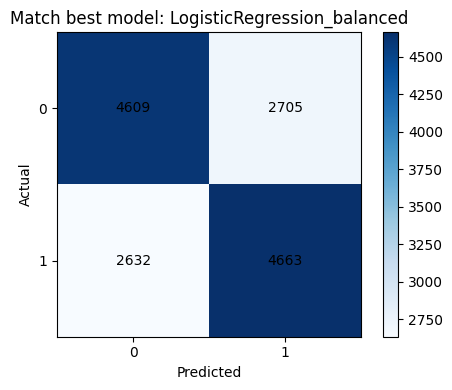

              precision    recall  f1-score   support

           0     0.6365    0.6302    0.6333      7314
           1     0.6329    0.6392    0.6360      7295

    accuracy                         0.6347     14609
   macro avg     0.6347    0.6347    0.6347     14609
weighted avg     0.6347    0.6347    0.6347     14609



,error_type,rows
0,all_test,14609
1,errors,5337
2,confident_wrong,30
3,false_positive,30
4,false_negative,30


,feature,importance
3,is_home,0.520461
120,team_win_rate_last10_diff,0.373786
90,team_possessions_proxy_last10_diff,0.242413
42,roster_total_points_diff,0.173363
94,team_possessions_proxy_last5_diff,0.151336
46,roster_weighted_age_by_minutes_diff,0.145796
102,team_reb_last10_diff,0.127510
37,roster_players_count,0.123581
17,opp_roster_total_points,0.119340
41,roster_total_points,0.117297


In [ ]:
if best_match_model is not None:
    Xt = get_numeric_feature_frame(match_test, best_match_info["features"]).reindex(columns=best_match_info["features"])
    yt = match_test["target_win"].astype(int)
    pred, score = predict_classification_outputs(best_match_model, Xt)
    plot_confusion_matrix(yt, pred, f"Match best model: {best_match_info['model_name']}", FIG_DIR / "match_confusion_matrix.png")
    print(classification_report(yt, pred, digits=4, zero_division=0))
    pred_df = pd.DataFrame({"game_date": match_test["game_date"].values, "team": match_test["team"].values if "team" in match_test.columns else None, "opponent": match_test["opponent"].values if "opponent" in match_test.columns else None, "target_win": yt.values, "predicted_class": pred, "predicted_score": score if score is not None else np.nan})
    pred_df["absolute_probability_error"] = np.abs(pred_df["target_win"] - pred_df["predicted_score"])
    pred_df["is_error"] = (pred_df["target_win"] != pred_df["predicted_class"]).astype(int)
    save_results_table(pred_df, TABLE_DIR / "match_test_predictions.csv")
    confident_wrong = pred_df.dropna(subset=["predicted_score"]).query("is_error == 1 and (predicted_score >= 0.80 or predicted_score <= 0.20)").head(30)
    false_positive = pred_df.query("target_win == 0 and predicted_class == 1").head(30)
    false_negative = pred_df.query("target_win == 1 and predicted_class == 0").head(30)
    save_results_table(confident_wrong, TABLE_DIR / "match_confident_wrong_predictions.csv")
    save_results_table(false_positive, TABLE_DIR / "match_false_positives.csv")
    save_results_table(false_negative, TABLE_DIR / "match_false_negatives.csv")
    match_error_summary = pd.DataFrame({"error_type": ["all_test", "errors", "confident_wrong", "false_positive", "false_negative"], "rows": [len(pred_df), int(pred_df["is_error"].sum()), len(confident_wrong), len(false_positive), len(false_negative)]})
    save_results_table(match_error_summary, TABLE_DIR / "match_error_summary.csv")
    fi = get_feature_importance(best_match_model, best_match_info["features"])
    save_results_table(fi, TABLE_DIR / "match_feature_importance.csv")
    joblib.dump(best_match_model, MODEL_DIR / "best_match_winner_model.joblib")
    display(match_error_summary); display(fi.head(15))
else:
    print("Лучшая модель классификации не была обучена; проверьте результаты предыдущих ячеек.")


## 12. Match Research Conclusions

Сопоставление baseline и classical ML-моделей позволяет определить устойчивый ориентир для задачи классификации исхода матча. Если ансамбли улучшают validation/test ROC-AUC относительно dummy и линейных моделей, это поддерживает гипотезу о нелинейных взаимодействиях признаков формы, состава и контекста. При интерпретации результата важно учитывать временной дрейф состава команд и возможную неполноту новостных признаков.


## 13. Part 2 Research Setup

Задача 2 формулируется как регрессия на уровне «игрок × матч» с целевой переменной target_points.


In [ ]:
player_points_df_raw = pd.read_csv(PLAYER_POINTS_DATASET_PATH)
player_points_feature_sets = load_json(PLAYER_POINTS_FEATURE_SETS_PATH)
print(f"player_points_df_raw shape: {player_points_df_raw.shape}")


player_points_df_raw shape: (243845, 154)


## 14. Load Player Points Dataset

Проводится очистка дат, целевой переменной и дубликатов. Для очков игрока дополнительно отсекаются отрицательные и явно некорректные значения.


In [ ]:
player_points_df = clean_model_dataset(player_points_df_raw, "game_date", "target_points", "player points prediction dataset", min_year=1910, target_min=0, target_max=100)
player_points_df["target_points"] = player_points_df["target_points"].astype(float)
player_summary = summarize_dataset(player_points_df, "game_date", "target_points", ["player", "team", "opponent", "game_id"], "player_points_prediction_dataset")
save_results_table(player_summary, TABLE_DIR / "player_points_dataset_quality_summary.csv")
display(player_summary)


,dataset,rows,columns,duplicates,date_min,date_max,target_missing,target_mean,mean_missing_share,n_player,n_team,n_opponent,n_game_id
0,player_points_prediction_dataset,243844,154,0,1946-11-01,1974-12-30,0,10.7297,0.541572,1241,47,47,11810


## 15. Player Points Feature Set Selection

Формируются несколько наборов признаков для ablation: форма игрока, предыдущий сезон, командный и сопернический контекст, финансы, новости и полный набор. Потенциальная утечка целевой переменной исключается по названию колонок.


In [ ]:
p_form = get_feature_group(player_points_feature_sets, "player_form_features", player_points_df)
p_prev = get_feature_group(player_points_feature_sets, "previous_season_features", player_points_df)
p_team = get_feature_group(player_points_feature_sets, "team_context_features", player_points_df)
p_opp = get_feature_group(player_points_feature_sets, "opponent_context_features", player_points_df)
p_fin = get_feature_group(player_points_feature_sets, "financial_features", player_points_df)
p_news = get_feature_group(player_points_feature_sets, "news_features", player_points_df)
p_all = get_feature_group(player_points_feature_sets, "all_model_features", player_points_df)
all_player_features = sorted(set(p_all if p_all else p_form + p_prev + p_team + p_opp + p_fin + p_news))
all_player_features = remove_potential_leakage_features(all_player_features, "target_points", task="player")
player_points_df, all_player_features = add_ratio_features(player_points_df, all_player_features, max_new_features=16)
player_feature_ablation = {
    "player_form_only": sorted(set(remove_potential_leakage_features(p_form, "target_points", task="player"))),
    "player_form_plus_previous_season": sorted(set(remove_potential_leakage_features(p_form + p_prev, "target_points", task="player"))),
    "player_form_plus_context": sorted(set(remove_potential_leakage_features(p_form + p_prev + p_team + p_opp, "target_points", task="player"))),
    "all_features": sorted(set(all_player_features)),
}
player_feature_ablation = {k: validate_columns(player_points_df, v, f"player_points:{k}") for k, v in player_feature_ablation.items() if v}
player_feature_set_summary = pd.DataFrame([{"feature_set": k, "n_features": len(v)} for k, v in player_feature_ablation.items()])
save_results_table(player_feature_set_summary, TABLE_DIR / "player_points_feature_set_summary.csv")
display(player_feature_set_summary)


,feature_set,n_features
0,player_form_only,47
1,player_form_plus_previous_season,75
2,player_form_plus_context,95
3,all_features,151


## 16. Player Points Chronological Split

Хронологическое разбиение предотвращает обучение на будущих матчах. Распределение целевой переменной по split проверяется визуально.


,split,rows,date_min,date_max,target_mean,target_std
0,train,170690,1946-11-01,1969-11-25,10.505238,8.452300
1,validation,36577,1969-11-25,1972-02-23,11.651612,9.075045
2,test,36577,1972-02-23,1974-12-30,10.855264,8.756412


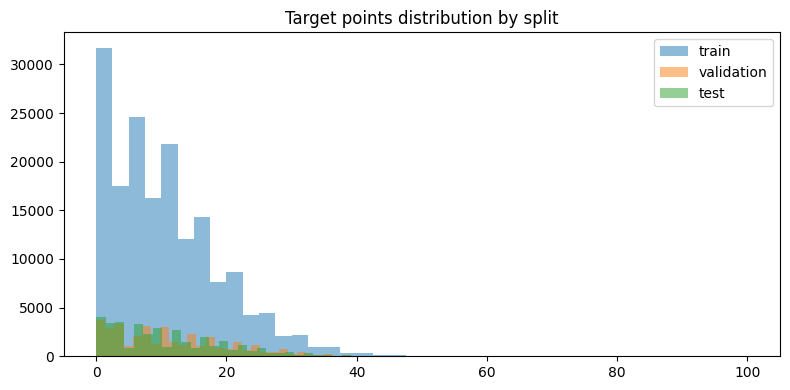

In [ ]:
pp_train, pp_val, pp_test = chronological_split(player_points_df, "game_date", 0.70, 0.15)
pp_split_summary = split_report(pp_train, pp_val, pp_test, "game_date", "target_points")
save_results_table(pp_split_summary, TABLE_DIR / "player_points_split_summary.csv")
display(pp_split_summary)
plt.figure(figsize=(8, 4))
plt.hist(pp_train["target_points"].dropna(), bins=40, alpha=0.5, label="train")
plt.hist(pp_val["target_points"].dropna(), bins=40, alpha=0.5, label="validation")
plt.hist(pp_test["target_points"].dropna(), bins=40, alpha=0.5, label="test")
plt.legend(); plt.title("Target points distribution by split"); plt.tight_layout()
plt.savefig(FIG_DIR / "player_points_split_target_distribution.png", dpi=150)
plt.show()


## 17. Player Points Regression Model Zoo

Регрессионный набор моделей также компактный: dummy-baseline, линейные модели, KNN, дерево, random forest, extra trees и gradient boosting. Это снижает время выполнения в Colab и сохраняет сопоставимость результатов.


In [ ]:
reg_models = [
    model_rec("Dummy_mean", "dummy", DummyRegressor(strategy="mean")),
    model_rec("Dummy_median", "dummy", DummyRegressor(strategy="median")),
    model_rec("Ridge", "linear", Ridge(random_state=RANDOM_STATE), "scaled"),
    model_rec("ElasticNet", "linear", ElasticNet(random_state=RANDOM_STATE, max_iter=1000), "scaled"),
    model_rec("LinearSVR", "svm", LinearSVR(random_state=RANDOM_STATE, max_iter=2500), "scaled"),
    model_rec("KNeighborsRegressor", "metric", KNeighborsRegressor(n_neighbors=21), "scaled", knn=True),
    model_rec("DecisionTreeRegressor", "tree", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8, min_samples_leaf=10)),
    model_rec("RandomForestRegressor", "tree_ensemble", RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12, min_samples_leaf=5), heavy=True),
    model_rec("ExtraTreesRegressor", "tree_ensemble", ExtraTreesRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12, min_samples_leaf=5), heavy=True),
    model_rec("GradientBoostingRegressor", "boosting", GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=90, learning_rate=0.06, max_depth=2), heavy=True),
    model_rec("HistGradientBoostingRegressor", "boosting", HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=90, learning_rate=0.06, max_leaf_nodes=15), heavy=True),
]
if XGBRegressor is not None:
    reg_models.append(model_rec("XGBRegressor", "external_boosting", XGBRegressor(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.07, max_depth=4, subsample=0.9, colsample_bytree=0.9), heavy=True))
if LGBMRegressor is not None:
    reg_models.append(model_rec("LGBMRegressor", "external_boosting", LGBMRegressor(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.07, max_depth=8, verbose=-1), heavy=True))
if CatBoostRegressor is not None:
    reg_models.append(model_rec("CatBoostRegressor", "external_boosting", CatBoostRegressor(random_state=RANDOM_STATE, iterations=100, learning_rate=0.07, depth=5, verbose=False), heavy=True))

display(pd.DataFrame([{k: v for k, v in rec.items() if k != "estimator"} for rec in reg_models]))


,name,family,pipe,heavy,knn
0,Dummy_mean,dummy,tree,False,False
1,Dummy_median,dummy,tree,False,False
2,Ridge,linear,scaled,False,False
3,ElasticNet,linear,scaled,False,False
4,LinearSVR,svm,scaled,False,False
5,KNeighborsRegressor,metric,scaled,False,True
6,DecisionTreeRegressor,tree,tree,False,False
7,RandomForestRegressor,tree_ensemble,tree,True,False
8,ExtraTreesRegressor,tree_ensemble,tree,True,False
9,GradientBoostingRegressor,boosting,tree,True,False


## 18. Player Points Baseline Training Loop

Модели обучаются на train и оцениваются на validation/test. Основная метрика выбора для регрессии - MAE на validation.


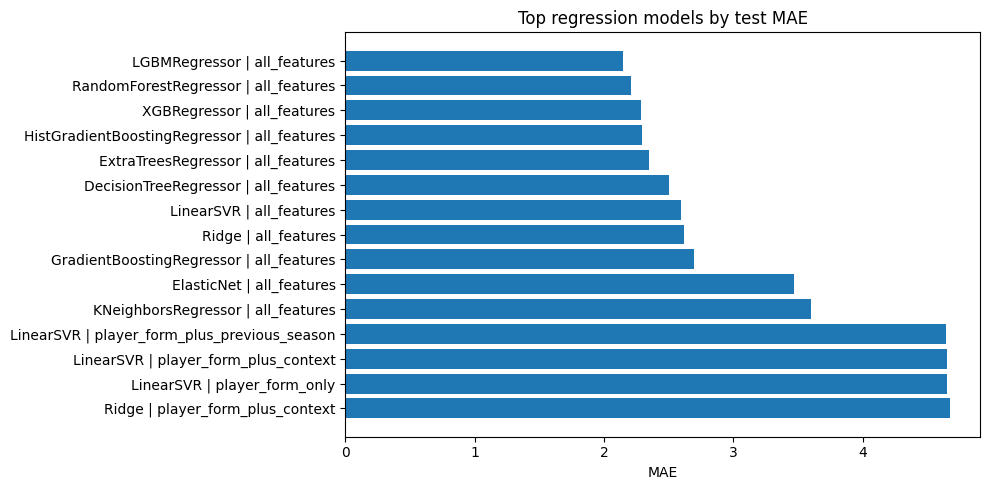

,task,feature_set,model_family,model,status,trained_on_sample,fit_time_sec,predict_time_sec,split_type,n_features,n_train,n_val,n_test,mae_val,rmse_val,r2_val,mape_val,mae_test,rmse_test,r2_test,mape_test,main_validation_metric,main_test_metric,params,error_message,comment_for_thesis
51,player_points_regression,all_features,external_boosting,LGBMRegressor,trained,True,3.412625,0.481141,chronological,74,170690,36577,36577,1.925647,2.778894,0.906231,23.324682,2.145115,3.105478,0.874219,28.648791,1.925647,2.145115,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
46,player_points_regression,all_features,tree_ensemble,RandomForestRegressor,trained,True,138.188009,0.960382,chronological,74,170690,36577,36577,1.972272,2.863621,0.900426,24.469774,2.208907,3.198671,0.866556,30.504180,1.972272,2.208907,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
50,player_points_regression,all_features,external_boosting,XGBRegressor,trained,True,1.887215,0.152295,chronological,74,170690,36577,36577,2.046179,2.918809,0.896551,25.433069,2.286377,3.263428,0.861098,31.225760,2.046179,2.286377,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
49,player_points_regression,all_features,boosting,HistGradientBoostingRegressor,trained,True,2.215647,0.545921,chronological,74,170690,36577,36577,2.066862,2.942624,0.894856,26.032583,2.296938,3.272306,0.860342,31.460476,2.066862,2.296938,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
47,player_points_regression,all_features,tree_ensemble,ExtraTreesRegressor,trained,True,45.920720,0.944815,chronological,74,170690,36577,36577,2.100699,2.990817,0.891384,27.502407,2.350190,3.331429,0.855249,34.003028,2.100699,2.350190,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
45,player_points_regression,all_features,tree,DecisionTreeRegressor,trained,True,5.440528,0.074778,chronological,74,170690,36577,36577,2.320752,3.301265,0.867665,28.933352,2.498435,3.554054,0.835257,33.941708,2.320752,2.498435,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
43,player_points_regression,all_features,svm,LinearSVR,trained,True,215.887507,0.098295,chronological,74,170690,36577,36577,2.386673,3.447605,0.855672,30.803356,2.594686,3.844542,0.807226,34.730670,2.386673,2.594686,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
41,player_points_regression,all_features,linear,Ridge,trained,True,1.269931,0.090369,chronological,74,170690,36577,36577,2.430628,3.428477,0.857270,32.395589,2.617708,3.784507,0.813200,35.777482,2.430628,2.617708,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
48,player_points_regression,all_features,boosting,GradientBoostingRegressor,trained,True,37.632921,0.171831,chronological,74,170690,36577,36577,2.513033,3.500175,0.851237,33.282019,2.693843,3.746709,0.816912,37.851581,2.513033,2.693843,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...
42,player_points_regression,all_features,linear,ElasticNet,trained,True,1.667759,0.095128,chronological,74,170690,36577,36577,3.444709,4.456624,0.758828,51.631350,3.471196,4.500281,0.735857,54.660815,3.444709,3.471196,"{'memory': None, 'steps': [('imputer', SimpleI...",,Модель обучена на train и оценена на validatio...


In [ ]:
reg_results = []
for fs_name, fs_cols in player_feature_ablation.items():
    X_train = get_numeric_feature_frame(pp_train, fs_cols)
    X_val = get_numeric_feature_frame(pp_val, fs_cols).reindex(columns=X_train.columns)
    X_test = get_numeric_feature_frame(pp_test, fs_cols).reindex(columns=X_train.columns)
    y_train = pp_train["target_points"].astype(float); y_val = pp_val["target_points"].astype(float); y_test = pp_test["target_points"].astype(float)
    for rec in reg_models:
        row = {"task": "player_points_regression", "feature_set": fs_name, "model_family": rec["family"], "model": rec["name"], "status": "trained", "trained_on_sample": False, "fit_time_sec": np.nan, "predict_time_sec": np.nan, "split_type": "chronological", "n_features": X_train.shape[1], "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test), "mae_val": np.nan, "rmse_val": np.nan, "r2_val": np.nan, "mape_val": np.nan, "mae_test": np.nan, "rmse_test": np.nan, "r2_test": np.nan, "mape_test": np.nan, "main_validation_metric": np.nan, "main_test_metric": np.nan, "params": "", "error_message": "", "comment_for_thesis": ""}
        try:
            limit = MAX_ROWS_FOR_KNN if rec.get("knn") else (MAX_ROWS_FOR_HEAVY_MODELS if rec.get("heavy") else MAX_ROWS_FOR_BASE_MODELS)
            Xtr, ytr, sampled = sample_training_data(X_train, y_train, limit); row["trained_on_sample"] = sampled
            model = build_pipeline(rec["pipe"], clone(rec["estimator"]))
            t0 = time.time(); model.fit(Xtr, ytr); row["fit_time_sec"] = time.time() - t0
            t1 = time.time(); pred_val = model.predict(X_val); pred_test = model.predict(X_test); row["predict_time_sec"] = time.time() - t1
            mv = regression_metrics(y_val, pred_val); mt = regression_metrics(y_test, pred_test)
            for metric in ["mae", "rmse", "r2", "mape"]:
                row[f"{metric}_val"] = mv[metric]; row[f"{metric}_test"] = mt[metric]
            row["main_validation_metric"] = mv["mae"]; row["main_test_metric"] = mt["mae"]
            row["params"] = str(model.get_params())[:1500]
            row["comment_for_thesis"] = "Модель обучена на train и оценена на validation/test без перемешивания временного порядка."
        except Exception as exc:
            row["status"] = "failed"; row["error_message"] = str(exc)[:1000]; row["comment_for_thesis"] = "Модель исключена из сравнения из-за ошибки."
        reg_results.append(row)
reg_results_df = pd.DataFrame(reg_results)
save_results_table(reg_results_df, TABLE_DIR / "player_points_regression_results.csv")
plot_barh_top(reg_results_df, "main_test_metric", True, "Top regression models by test MAE", "MAE", FIG_DIR / "player_points_regression_top_models.png")
display(reg_results_df.sort_values("main_validation_metric", ascending=True, na_position="last").head(15))


## 19. Player Points Hyperparameter Tuning

Подбор гиперпараметров выполняется только на train с TimeSeriesSplit. Лучшая tuned-модель выбирается по validation MAE.


In [ ]:
reg_tuning_configs = {
    "Ridge": {"estimator": Ridge(random_state=RANDOM_STATE), "pipe": "scaled", "params": {"model__alpha": np.logspace(-2, 2, 10)}},
    "RandomForestRegressor": {"estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), "pipe": "tree", "params": {"model__n_estimators": [80, 120, 160], "model__max_depth": [8, 12, None], "model__min_samples_leaf": [3, 5, 10], "model__max_features": ["sqrt", 0.7, 1.0]}},
    "ExtraTreesRegressor": {"estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1), "pipe": "tree", "params": {"model__n_estimators": [80, 120, 160], "model__max_depth": [8, 12, None], "model__min_samples_leaf": [3, 5, 10], "model__max_features": ["sqrt", 0.7, 1.0]}},
    "HistGradientBoostingRegressor": {"estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE), "pipe": "tree", "params": {"model__learning_rate": [0.03, 0.06, 0.1], "model__max_iter": [60, 100], "model__max_leaf_nodes": [15, 31]}},
}
feature_set_name = "all_features" if "all_features" in player_feature_ablation else next(iter(player_feature_ablation))
feature_cols = player_feature_ablation[feature_set_name]
X_train = get_numeric_feature_frame(pp_train, feature_cols)
X_val = get_numeric_feature_frame(pp_val, feature_cols).reindex(columns=X_train.columns)
X_test = get_numeric_feature_frame(pp_test, feature_cols).reindex(columns=X_train.columns)
y_train = pp_train["target_points"].astype(float); y_val = pp_val["target_points"].astype(float); y_test = pp_test["target_points"].astype(float)
if len(X_train) > MAX_ROWS_FOR_HEAVY_MODELS:
    X_train_tune = X_train.iloc[-MAX_ROWS_FOR_HEAVY_MODELS:].copy()
    y_train_tune = y_train.iloc[-MAX_ROWS_FOR_HEAVY_MODELS:].copy()
    tune_sampled = True
else:
    X_train_tune = X_train
    y_train_tune = y_train
    tune_sampled = False
ts_cv = TimeSeriesSplit(n_splits=3)
reg_tuning_rows = []; trained_reg_tuned = {}
for model_name, config in reg_tuning_configs.items():
    row = {"task": "player_points_regression", "feature_set": feature_set_name, "model": model_name, "status": "trained", "best_params": "", "cv_best_neg_mae": np.nan, "mae_val": np.nan, "rmse_val": np.nan, "r2_val": np.nan, "mae_test": np.nan, "rmse_test": np.nan, "r2_test": np.nan, "fit_time_sec": np.nan, "trained_on_sample": tune_sampled, "comment_for_thesis": "RandomizedSearchCV с TimeSeriesSplit на train; выбор по validation.", "error_message": ""}
    try:
        search = RandomizedSearchCV(build_pipeline(config["pipe"], clone(config["estimator"])), config["params"], n_iter=TUNING_N_ITER, scoring="neg_mean_absolute_error", cv=ts_cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True, error_score=np.nan)
        t0 = time.time(); search.fit(X_train_tune, y_train_tune); row["fit_time_sec"] = time.time() - t0
        best_model = search.best_estimator_
        pred_val = best_model.predict(X_val); pred_test = best_model.predict(X_test)
        mv = regression_metrics(y_val, pred_val); mt = regression_metrics(y_test, pred_test)
        row.update({"best_params": str(search.best_params_), "cv_best_neg_mae": search.best_score_, "mae_val": mv["mae"], "rmse_val": mv["rmse"], "r2_val": mv["r2"], "mae_test": mt["mae"], "rmse_test": mt["rmse"], "r2_test": mt["r2"]})
        trained_reg_tuned[model_name] = best_model
    except Exception as exc:
        row["status"] = "failed"; row["error_message"] = str(exc)[:1000]
    reg_tuning_rows.append(row)
reg_tuning_df = pd.DataFrame(reg_tuning_rows).sort_values("mae_val", ascending=True, na_position="last")
save_results_table(reg_tuning_df, TABLE_DIR / "player_points_tuning_results.csv")
best_reg_model = None; best_reg_info = None
trained_tuned_reg = reg_tuning_df[reg_tuning_df["status"].eq("trained") & reg_tuning_df["mae_val"].notna()]
if not trained_tuned_reg.empty:
    best_row = trained_tuned_reg.iloc[0]
    best_reg_model = trained_reg_tuned[best_row["model"]]
    best_reg_info = {"model_name": best_row["model"], "feature_set_name": feature_set_name, "features": X_train.columns.tolist(), "validation_mae": best_row["mae_val"], "test_mae": best_row["mae_test"], "selection_source": "tuning_validation"}
else:
    trained_reg = reg_results_df[reg_results_df["status"].eq("trained") & reg_results_df["main_validation_metric"].notna()]
    if not trained_reg.empty:
        best_row = trained_reg.sort_values("main_validation_metric", ascending=True).iloc[0]
        rec = next(r for r in reg_models if r["name"] == best_row["model"])
        cols = player_feature_ablation[best_row["feature_set"]]
        Xtr = get_numeric_feature_frame(pp_train, cols); ytr = pp_train["target_points"].astype(float)
        best_reg_model = build_pipeline(rec["pipe"], clone(rec["estimator"])); best_reg_model.fit(Xtr, ytr)
        best_reg_info = {"model_name": best_row["model"], "feature_set_name": best_row["feature_set"], "features": Xtr.columns.tolist(), "validation_mae": best_row["main_validation_metric"], "test_mae": best_row["main_test_metric"], "selection_source": "baseline_validation"}

display(reg_tuning_df)


,task,feature_set,model,status,best_params,cv_best_neg_mae,mae_val,rmse_val,r2_val,mae_test,rmse_test,r2_test,fit_time_sec,trained_on_sample,comment_for_thesis,error_message
1,player_points_regression,all_features,RandomForestRegressor,trained,"{'model__n_estimators': 120, 'model__min_sampl...",-2.190883,1.893685,2.781132,0.906080,2.061296,3.062375,0.877686,739.133086,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
3,player_points_regression,all_features,HistGradientBoostingRegressor,trained,"{'model__max_leaf_nodes': 31, 'model__max_iter...",-2.202305,1.896266,2.735956,0.909107,2.051593,3.008030,0.881989,28.064669,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
2,player_points_regression,all_features,ExtraTreesRegressor,trained,"{'model__n_estimators': 120, 'model__min_sampl...",-2.243839,1.944705,2.833971,0.902477,2.114402,3.105285,0.874234,234.972668,True,RandomizedSearchCV с TimeSeriesSplit на train;...,
0,player_points_regression,all_features,Ridge,trained,{'model__alpha': np.float64(12.915496650148826)},-2.665772,2.385381,3.300725,0.867708,2.541194,3.584206,0.832450,10.253111,True,RandomizedSearchCV с TimeSeriesSplit на train;...,


## 20. Player Points Final Evaluation and Error Analysis

Для лучшей модели сохраняются предсказания, residual analysis, ошибки по диапазонам целевой переменной и важность признаков.


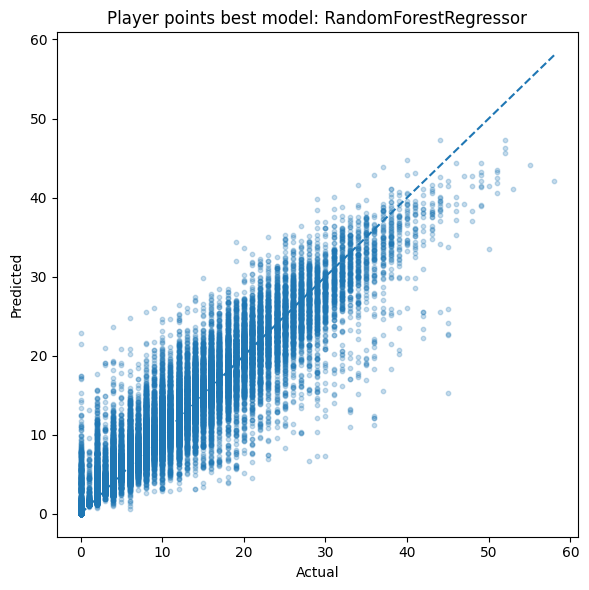

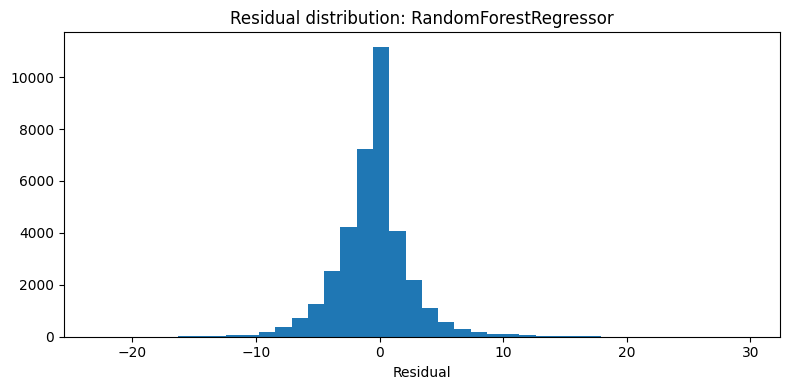

,target_bin,rows,mae,residual_mean
0,0-5,11937,1.234285,-1.084782
1,6-10,8592,1.956240,-1.085659
2,11-20,10602,2.485301,-0.435382
3,21+,5446,3.214323,1.447167


,feature,importance
0,efficiency_score,0.645568
34,player_pts_last10,0.135640
73,true_shooting_pct,0.057150
5,fg_pct,0.018425
23,player_fgm_last10,0.016359
36,player_pts_last5,0.015851
20,player_fga_last10,0.014658
37,player_reb_last10,0.010758
59,previous_trb_per_36_season,0.008036
6,minutes,0.006022


In [ ]:
if best_reg_model is not None:
    Xt = get_numeric_feature_frame(pp_test, best_reg_info["features"]).reindex(columns=best_reg_info["features"])
    yt = pp_test["target_points"].astype(float)
    pred = best_reg_model.predict(Xt)
    plot_regression_actual_vs_predicted(yt.values, pred, f"Player points best model: {best_reg_info['model_name']}", FIG_DIR / "player_points_actual_vs_predicted.png")
    plot_residual_distribution(yt.values, pred, f"Residual distribution: {best_reg_info['model_name']}", FIG_DIR / "player_points_residual_distribution.png")
    ppred = pd.DataFrame({"game_date": pp_test["game_date"].values, "player": pp_test["player"].values if "player" in pp_test.columns else None, "team": pp_test["team"].values if "team" in pp_test.columns else None, "opponent": pp_test["opponent"].values if "opponent" in pp_test.columns else None, "target_points": yt.values, "predicted_points": pred})
    ppred["absolute_error"] = np.abs(ppred["target_points"] - ppred["predicted_points"])
    ppred["residual"] = ppred["target_points"] - ppred["predicted_points"]
    save_results_table(ppred, TABLE_DIR / "player_points_test_predictions.csv")
    bins = [-np.inf, 5, 10, 20, np.inf]; labels = ["0-5", "6-10", "11-20", "21+"]
    ppred["target_bin"] = pd.cut(ppred["target_points"], bins=bins, labels=labels)
    error_by_bin = ppred.groupby("target_bin", dropna=False, observed=False).agg(rows=("absolute_error", "size"), mae=("absolute_error", "mean"), residual_mean=("residual", "mean")).reset_index()
    save_results_table(error_by_bin, TABLE_DIR / "player_points_error_by_target_bins.csv")
    save_results_table(ppred.sort_values("absolute_error", ascending=False).head(100), TABLE_DIR / "player_points_top_errors.csv")
    fi = get_feature_importance(best_reg_model, best_reg_info["features"])
    save_results_table(fi, TABLE_DIR / "player_points_feature_importance.csv")
    joblib.dump(best_reg_model, MODEL_DIR / "best_player_points_model.joblib")
    display(error_by_bin); display(fi.head(15))
else:
    print("Лучшая регрессионная модель не была обучена; проверьте результаты предыдущих ячеек.")


## 21. Player Points Research Conclusions

Сравнение baseline и classical ML-моделей по MAE/RMSE/R2/MAPE фиксирует практический предел качества табличных методов для задачи индивидуальной результативности. Снижение MAE относительно dummy baseline показывает, что историческая форма и контекст матча дают предиктивный сигнал. Анализ ошибок по диапазонам очков помогает выявить, где модель систематически недооценивает высокорезультативные матчи или переоценивает игроков с малой ролью.


## 22. Comparison of Both Tasks

Итоговое сравнение фиксирует лучшие модели, выбранные по validation, и их прирост относительно наивных baseline на test.


In [ ]:
baseline_cls = match_results_df[match_results_df["status"].eq("trained") & match_results_df["model_family"].eq("dummy") & match_results_df["main_test_metric"].notna()].sort_values("main_test_metric", ascending=False).head(1)
baseline_reg = reg_results_df[reg_results_df["status"].eq("trained") & reg_results_df["model_family"].eq("dummy") & reg_results_df["main_test_metric"].notna()].sort_values("main_test_metric", ascending=True).head(1)
rows = []
if best_match_info is not None:
    b = baseline_cls["main_test_metric"].iloc[0] if not baseline_cls.empty else np.nan
    v = best_match_info.get("test_roc_auc", np.nan)
    rows.append({"task": "match_winner_classification", "best_model": best_match_info["model_name"], "best_feature_set": best_match_info["feature_set_name"], "selection_metric": "validation_roc_auc", "test_metric": "roc_auc", "test_metric_value": v, "baseline_test_metric_value": b, "improvement_over_baseline": (v - b) if pd.notna(b) and pd.notna(v) else np.nan, "interpretation": "Положительный прирост ROC-AUC указывает на полезность расширенных признаков и нелинейных моделей."})
if best_reg_info is not None:
    b = baseline_reg["main_test_metric"].iloc[0] if not baseline_reg.empty else np.nan
    v = best_reg_info.get("test_mae", np.nan)
    rows.append({"task": "player_points_regression", "best_model": best_reg_info["model_name"], "best_feature_set": best_reg_info["feature_set_name"], "selection_metric": "validation_mae", "test_metric": "mae", "test_metric_value": v, "baseline_test_metric_value": b, "improvement_over_baseline": (b - v) if pd.notna(b) and pd.notna(v) else np.nan, "interpretation": "Снижение MAE относительно dummy baseline подтверждает вклад исторической формы и контекста игрока."})
summary_df = pd.DataFrame(rows)
save_results_table(summary_df, TABLE_DIR / "baseline_summary_all_tasks.csv")
display(summary_df)


,task,best_model,best_feature_set,selection_metric,test_metric,test_metric_value,baseline_test_metric_value,improvement_over_baseline,interpretation
0,match_winner_classification,LogisticRegression_balanced,all_features,validation_roc_auc,roc_auc,0.686153,0.505365,0.180788,Положительный прирост ROC-AUC указывает на пол...
1,player_points_regression,RandomForestRegressor,all_features,validation_mae,mae,2.061296,6.979632,4.918336,Снижение MAE относительно dummy baseline подтв...


## 23. Create docs/baseline_models.md

Формируется краткий отчет для текстовой части ВКР и фиксации методологических решений.


In [ ]:
doc_text = """# Baseline Models

## 1. Назначение этапа
Этап предназначен для построения baseline и classical ML-моделей по двум прогнозным задачам: исход матча и очки игрока. Результаты используются как воспроизводимый ориентир качества перед сравнением с deep learning.

## 2. Данные и очистка
Перед обучением проверяются обязательные колонки, корректность дат, диапазоны целевых переменных, дубликаты, пропуски и потенциальная утечка целевой переменной.

## 3. Валидационная схема
Для обеих задач используется хронологическое train/validation/test разбиение 70/15/15. Validation применяется для выбора модели и гиперпараметров, test используется только для финальной оценки.

## 4. Baseline и classical ML
Включены dummy-модели, линейные методы, метрические методы, деревья решений, random forest, extra trees, gradient boosting и внешние boosting-библиотеки при наличии в среде выполнения.

## 5. Метрики и tuning
Для классификации используются Accuracy, Precision, Recall, F1 и ROC-AUC. Для регрессии используются MAE, RMSE, R2 и MAPE. Tuning ограничен RandomizedSearchCV и TimeSeriesSplit на train.

## 6. Анализ ошибок
Для исходов матчей сохраняются confusion matrix, ложные срабатывания, пропуски и уверенные ошибки. Для очков игрока сохраняются residual plots, ошибки по диапазонам результативности и примеры крупнейших ошибок.

## 7. Ограничения
Качество ограничено полнотой исторических признаков, изменениями состава, травмами, ротацией игроков, качеством новостного покрытия и вычислительными лимитами тяжелых моделей.
"""
(DOCS_DIR / "baseline_models.md").write_text(doc_text, encoding="utf-8")
print(f"Создан файл: {DOCS_DIR / 'baseline_models.md'}")


Создан файл: /content/docs/baseline_models.md


## 24. Final Summary

Ноутбук строит воспроизводимый baseline для двух задач: классификация победителя матча и регрессия очков игрока. Реализованы очистка и проверка данных, контроль потенциальной утечки, компактный feature engineering, хронологическое разбиение, baseline-модели, classical ML, ограниченный tuning, анализ ошибок, сохранение таблиц/графиков/моделей и краткий отчет для ВКР.

Методологически важно, что выбор модели выполняется по validation, а test остается независимой финальной оценкой. Это делает результаты пригодными для академичного сравнения с последующими deep learning подходами.
